# Pipeline A — Step 2: First-Differences Model

$$\Delta Y_{it} = \beta \cdot \Delta X_{it} + \Delta \epsilon_{it}$$

Province FE eliminated: $\alpha_i - \alpha_i = 0$. Only ~9 params for ~93 obs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

def find_root(start):
    for p in [Path(start).resolve(), *Path(start).resolve().parents]:
        if (p / 'pipeline_A' / 'output' / 'A1_annual_panel.csv').exists(): return p
    raise FileNotFoundError('A1_annual_panel.csv not found')

ROOT = find_root(Path.cwd())
out = ROOT / 'pipeline_A' / 'output'
out.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(out / 'A1_annual_panel.csv')
print(f'Loaded annual panel: {len(df)} rows, {df["provinsi_id"].nunique()} provinces, years {sorted(df["tahun"].unique())}')

Loaded annual panel: 124 rows, 31 provinces, years [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [2]:
# === Compute First-Differences per province ===
target = 'twp90_avg'
econ_cols = ['x1_bi_rate_avg', 'x2_inflasi_avg', 'log_pdrb',
             'x4_tpt', 'x5_internet', 'x8_ldr', 'x9_npl', 'x10_umkm']

df = df.sort_values(['provinsi_id', 'tahun']).reset_index(drop=True)

# Fill missing x5_internet (2021) with bfill per province before differencing
df['x5_internet'] = df.groupby('provinsi_id')['x5_internet'].transform(lambda s: s.bfill())

# Compute deltas
diff_frames = []
for pid, grp in df.groupby('provinsi_id'):
    grp = grp.sort_values('tahun').copy()
    d = pd.DataFrame()
    d['provinsi_id'] = grp['provinsi_id'].iloc[1:].values
    d['nama_provinsi'] = grp['nama_provinsi'].iloc[1:].values
    d['tahun'] = grp['tahun'].iloc[1:].values
    d['y_level'] = grp[target].iloc[1:].values
    d['y_prev'] = grp[target].iloc[:-1].values
    d['dy'] = d['y_level'] - d['y_prev']
    for col in econ_cols:
        vals = grp[col].values
        d[f'd_{col}'] = vals[1:] - vals[:-1]
    diff_frames.append(d)

df_fd = pd.concat(diff_frames, ignore_index=True)
df_fd = df_fd.dropna().reset_index(drop=True)

dx_cols = [f'd_{c}' for c in econ_cols]
print(f'First-differences panel: {len(df_fd)} obs')
print(f'Years in diffs: {sorted(df_fd["tahun"].unique())}')
print(f'Features: {dx_cols}')
display(df_fd.head())

First-differences panel: 93 obs
Years in diffs: [np.int64(2023), np.int64(2024), np.int64(2025)]
Features: ['d_x1_bi_rate_avg', 'd_x2_inflasi_avg', 'd_log_pdrb', 'd_x4_tpt', 'd_x5_internet', 'd_x8_ldr', 'd_x9_npl', 'd_x10_umkm']


,provinsi_id,nama_provinsi,tahun,y_level,y_prev,dy,d_x1_bi_rate_avg,d_x2_inflasi_avg,d_log_pdrb,d_x4_tpt,d_x5_internet,d_x8_ldr,d_x9_npl,d_x10_umkm
0,1,Banten,2023,0.029208,0.025142,0.004067,1.812500,-0.002380,0.074242,-0.565,0.0810,0.0231,-0.0029,0.0016
1,1,Banten,2024,0.022292,0.029208,-0.006917,0.291667,0.022663,0.060551,-0.895,-0.0455,0.0009,0.0059,-0.0169
2,1,Banten,2025,0.024117,0.022292,0.001825,-0.812500,-0.007733,0.060688,-0.185,-0.0056,0.0055,0.0049,-0.0070
3,2,Dki Jakarta,2023,0.029475,0.025492,0.003983,1.812500,-0.001567,0.073873,-0.540,0.0356,0.0989,-0.0032,-0.0037
4,2,Dki Jakarta,2024,0.031242,0.029475,0.001767,0.291667,0.017142,0.065183,-0.930,0.0055,0.0847,-0.0013,-0.0032


In [3]:
# === Train/Test Split ===
train_mask = df_fd['tahun'] <= 2024
test_mask  = df_fd['tahun'] == 2025

# Build X with manual constant (ensures identical shape for train & test)
X_all = df_fd[dx_cols].astype(float).copy()
X_all.insert(0, 'const', 1.0)

X_train = X_all.loc[train_mask]
y_train = df_fd.loc[train_mask, 'dy'].astype(float)
X_test  = X_all.loc[test_mask]
y_test  = df_fd.loc[test_mask, 'dy'].astype(float)

print(f'Train: {len(X_train)} obs | Test: {len(X_test)} obs | Params: {X_train.shape[1]}')
print(f'Ratio obs:params = {len(X_train)/X_train.shape[1]:.1f}:1')

Train: 62 obs | Test: 31 obs | Params: 9
Ratio obs:params = 6.9:1


In [4]:
# === FIT: OLS on First-Differences (clustered SE by province) ===
model_fd = sm.OLS(y_train, X_train).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_fd.loc[train_mask, 'provinsi_id'].values}
)
print(model_fd.summary())

with open(out / 'A2_ols_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(model_fd.summary()))

                            OLS Regression Results                            
Dep. Variable:                     dy   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     1.679
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.145
Time:                        11:52:04   Log-Likelihood:                 231.70
No. Observations:                  62   AIC:                            -445.4
Df Residuals:                      53   BIC:                            -426.3
Df Model:                           8                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0031      0.004  

In [5]:
# === VIF Check ===
vif_data = X_train.copy()
vif_df = pd.DataFrame({
    'feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False)
print('=== VIF (>10 = severe, >5 = moderate) ===')
display(vif_df)

=== VIF (>10 = severe, >5 = moderate) ===


,feature,VIF
0,const,79.334291
2,d_x2_inflasi_avg,18.116926
1,d_x1_bi_rate_avg,17.928905
8,d_x10_umkm,1.318033
6,d_x8_ldr,1.227638
4,d_x4_tpt,1.206574
3,d_log_pdrb,1.101434
7,d_x9_npl,1.093409
5,d_x5_internet,1.084697


In [6]:
# === Evaluate ===
dy_train_pred = model_fd.predict(X_train)
dy_test_pred  = model_fd.predict(X_test)

# Reconstruct level: Y_hat = Y_{t-1} + dY_hat
test_df = df_fd.loc[test_mask].copy()
test_df['dy_pred'] = dy_test_pred.values
test_df['y_pred_level'] = test_df['y_prev'] + test_df['dy_pred']
test_df['y_naive'] = test_df['y_prev']  # naive = no change

train_df = df_fd.loc[train_mask].copy()
train_df['dy_pred'] = dy_train_pred.values
train_df['y_pred_level'] = train_df['y_prev'] + train_df['dy_pred']

def calc(yt, yp, name):
    m = ~(np.isnan(yt) | np.isnan(yp))
    return {'model': name, 'n': int(m.sum()),
            'rmse': np.sqrt(mean_squared_error(yt[m], yp[m])),
            'mae':  mean_absolute_error(yt[m], yp[m]),
            'r2':   r2_score(yt[m], yp[m])}

ml_train = calc(train_df['y_level'].values, train_df['y_pred_level'].values, 'FD OLS Level (Train)')
ml_test  = calc(test_df['y_level'].values, test_df['y_pred_level'].values, 'FD OLS Level (Test)')
mn_test  = calc(test_df['y_level'].values, test_df['y_naive'].values, 'Naive y=y_{t-1}')

print('='*70)
print(f'{"Model":<25} {"N":>4} {"RMSE":>10} {"MAE":>10} {"R2":>8}')
print('-'*70)
for m in [ml_train, ml_test, mn_test]:
    print(f'{m["model"]:<25} {m["n"]:>4} {m["rmse"]:>10.6f} {m["mae"]:>10.6f} {m["r2"]:>8.4f}')
print('='*70)

beat = ml_test['rmse'] < mn_test['rmse']
if beat:
    imp = (mn_test['rmse'] - ml_test['rmse']) / mn_test['rmse'] * 100
    print(f'\nModel beats naive by {imp:.1f}%')
else:
    print(f'\nModel worse than naive by {(ml_test["rmse"]/mn_test["rmse"]-1)*100:.1f}%')

gap = abs(ml_train['rmse'] - ml_test['rmse']) / ml_test['rmse'] * 100
print(f'Overfitting gap: {gap:.1f}%')

neg = (test_df['y_pred_level'] < 0).sum()
print(f'Negative predictions: {neg}/{len(test_df)}')

pd.DataFrame([ml_train, ml_test, mn_test]).to_csv(out / 'A2_metrics.csv', index=False)

Model                        N       RMSE        MAE       R2
----------------------------------------------------------------------
FD OLS Level (Train)        62   0.005764   0.003777   0.6549
FD OLS Level (Test)         31   0.006752   0.005380   0.4062
Naive y=y_{t-1}             31   0.004768   0.003195   0.7038

Model worse than naive by 41.6%
Overfitting gap: 14.6%
Negative predictions: 0/31


In [7]:
# === Coefficients ===
params = model_fd.params
pvals  = model_fd.pvalues
ci     = model_fd.conf_int()
feats  = [f for f in params.index if f != 'const']

coeff_df = pd.DataFrame({
    'feature': feats,
    'coefficient': params[feats].values,
    'p_value': pvals[feats].values,
    'ci_lower': ci.loc[feats, 0].values,
    'ci_upper': ci.loc[feats, 1].values,
    'significant_5pct': (pvals[feats] < 0.05).values,
}).sort_values('p_value').reset_index(drop=True)

print('=== First-Differences Coefficients ===')
display(coeff_df)
coeff_df.to_csv(out / 'A2_coefficients.csv', index=False)

=== First-Differences Coefficients ===


,feature,coefficient,p_value,ci_lower,ci_upper,significant_5pct
0,d_x9_npl,-0.259837,0.028759,-0.492723,-0.026950,True
1,d_x2_inflasi_avg,-0.247484,0.107229,-0.548617,0.053650,False
2,d_x8_ldr,0.020293,0.171787,-0.008813,0.049398,False
3,d_x5_internet,0.021696,0.187953,-0.010601,0.053993,False
4,d_x1_bi_rate_avg,-0.003272,0.225162,-0.008559,0.002015,False
5,d_x10_umkm,-0.040410,0.366406,-0.128098,0.047278,False
6,d_log_pdrb,0.006085,0.618843,-0.017889,0.030060,False
7,d_x4_tpt,0.000587,0.746398,-0.002968,0.004141,False


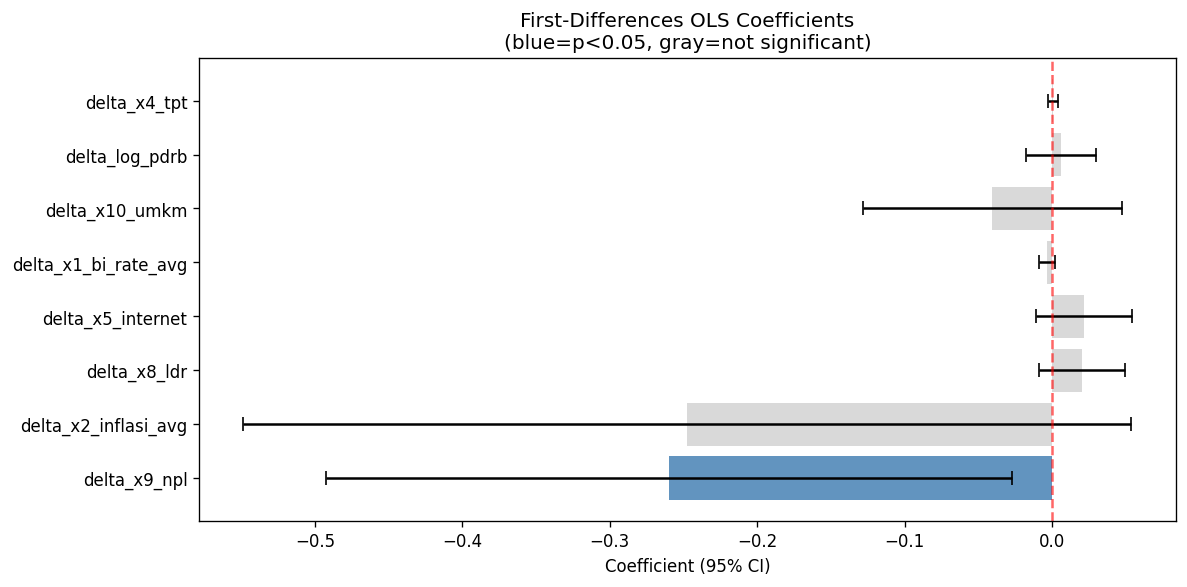

In [8]:
# === VIZ 1: Coefficient Plot ===
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(coeff_df))
colors = ['steelblue' if s else 'lightgray' for s in coeff_df['significant_5pct']]
ax.barh(y_pos, coeff_df['coefficient'], color=colors, alpha=0.85)
ax.errorbar(coeff_df['coefficient'], y_pos,
            xerr=[coeff_df['coefficient'] - coeff_df['ci_lower'],
                  coeff_df['ci_upper'] - coeff_df['coefficient']],
            fmt='none', color='black', capsize=4)
ax.axvline(0, color='red', ls='--', alpha=0.6)
labels = [f.replace('d_','delta_') for f in coeff_df['feature']]
ax.set_yticks(y_pos); ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (95% CI)')
ax.set_title('First-Differences OLS Coefficients\n(blue=p<0.05, gray=not significant)')
fig.tight_layout()
fig.savefig(out / 'A2_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()

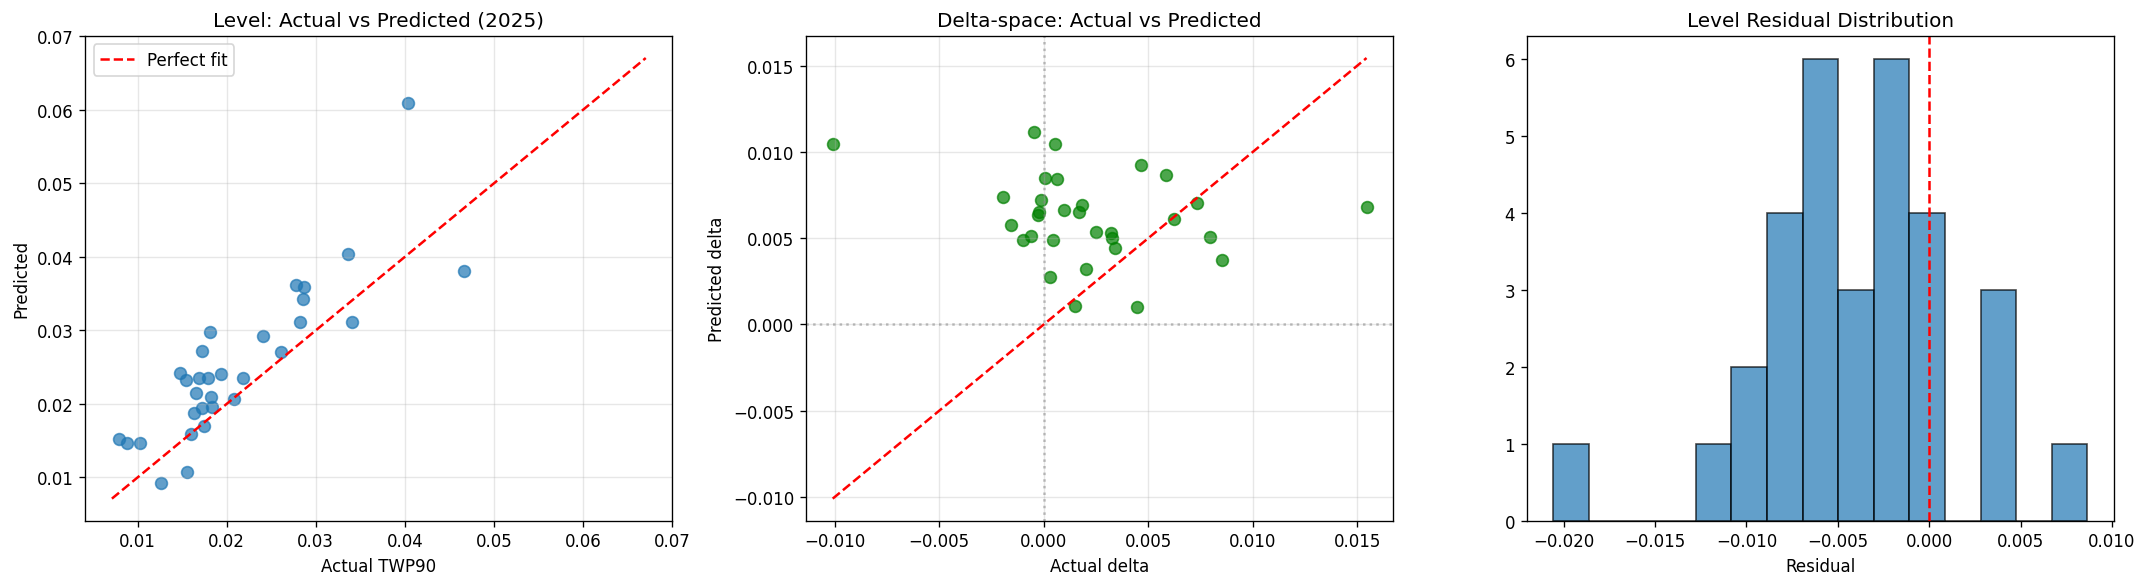

In [9]:
# === VIZ 2: Actual vs Predicted + Residuals ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(test_df['y_level'], test_df['y_pred_level'], alpha=0.7, s=50)
lims = [min(test_df['y_level'].min(), test_df['y_pred_level'].min()) * 0.9,
        max(test_df['y_level'].max(), test_df['y_pred_level'].max()) * 1.1]
ax.plot(lims, lims, 'r--', label='Perfect fit')
ax.set_xlabel('Actual TWP90'); ax.set_ylabel('Predicted')
ax.set_title('Level: Actual vs Predicted (2025)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y_test.values, dy_test_pred, alpha=0.7, s=50, color='green')
dlims = [min(y_test.min(), dy_test_pred.min()), max(y_test.max(), dy_test_pred.max())]
ax.plot(dlims, dlims, 'r--')
ax.axhline(0, color='gray', ls=':', alpha=0.5); ax.axvline(0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Actual delta'); ax.set_ylabel('Predicted delta')
ax.set_title('Delta-space: Actual vs Predicted'); ax.grid(True, alpha=0.3)

ax = axes[2]
resid = test_df['y_level'] - test_df['y_pred_level']
ax.hist(resid, bins=15, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', ls='--')
ax.set_title('Level Residual Distribution'); ax.set_xlabel('Residual')

fig.tight_layout()
fig.savefig(out / 'A2_prediction_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

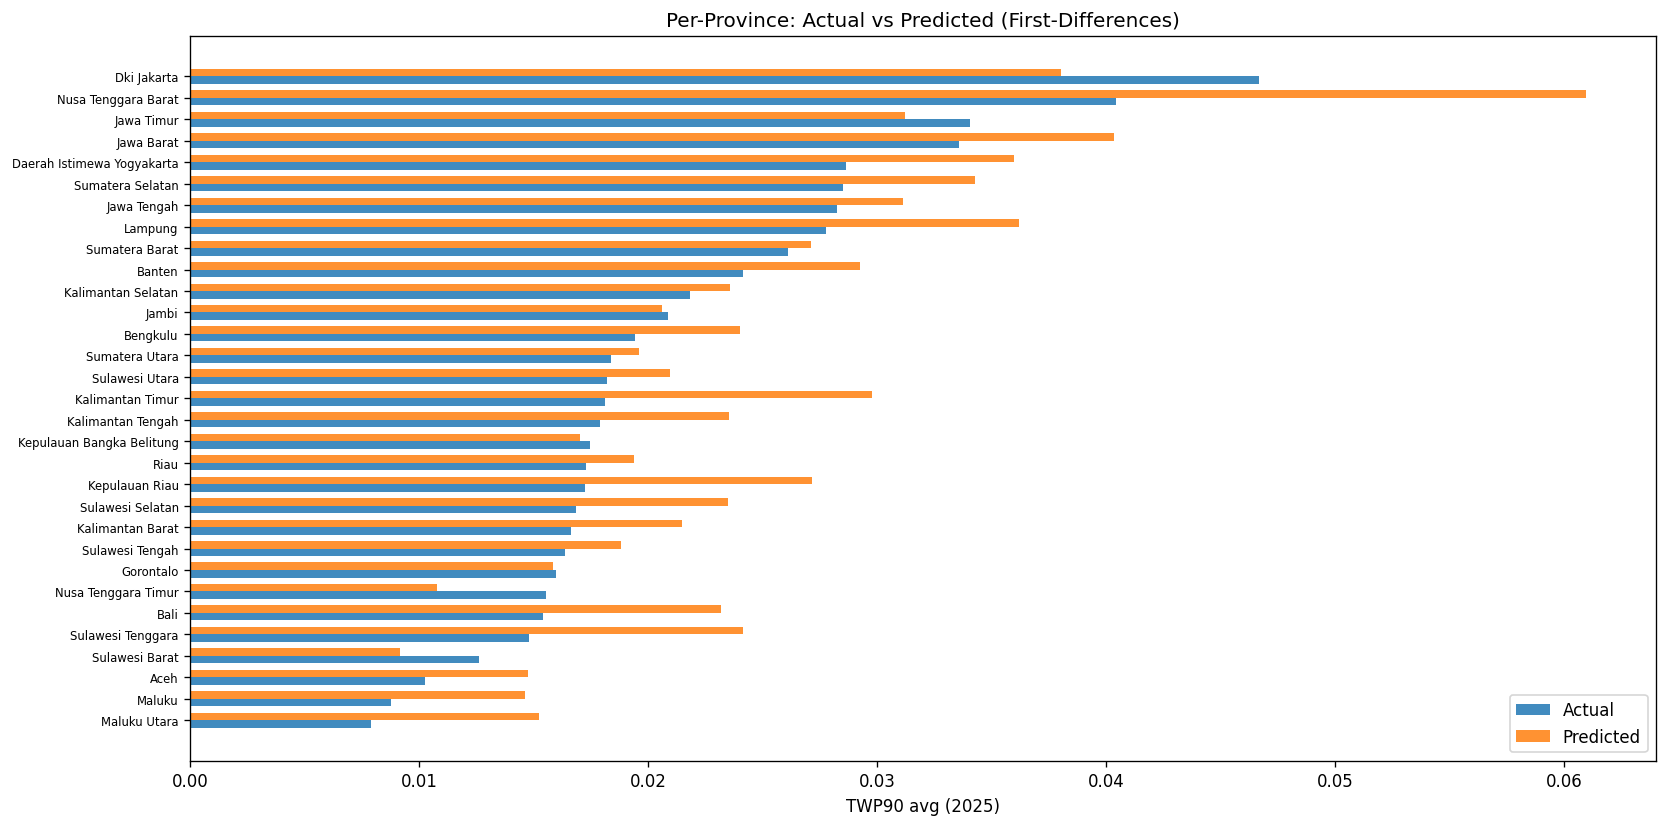

All outputs saved to: C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output


In [10]:
# === VIZ 3: Per-Province bar chart ===
prov_agg = test_df.groupby('nama_provinsi').agg(
    actual=('y_level','mean'), predicted=('y_pred_level','mean')
).sort_values('actual').reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(prov_agg)); w = 0.35
ax.barh(x - w/2, prov_agg['actual'],    w, label='Actual',    alpha=0.85)
ax.barh(x + w/2, prov_agg['predicted'], w, label='Predicted', alpha=0.85)
ax.set_yticks(x); ax.set_yticklabels(prov_agg['nama_provinsi'], fontsize=7)
ax.set_xlabel('TWP90 avg (2025)')
ax.set_title('Per-Province: Actual vs Predicted (First-Differences)')
ax.legend(); fig.tight_layout()
fig.savefig(out / 'A2_per_province_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

test_df[['provinsi_id','nama_provinsi','tahun','y_level','y_pred_level','y_naive','dy','dy_pred']].to_csv(
    out / 'A2_predictions.csv', index=False)
print(f'All outputs saved to: {out}')

In [11]:
# === FINAL SUMMARY ===
print('='*70)
print('PIPELINE A (First-Differences) - SUMMARY')
print('='*70)
print(f'Parameters: {X_train.shape[1]} | Train: {len(X_train)} | Ratio: {len(X_train)/X_train.shape[1]:.1f}:1')
print(f'Test RMSE:  {ml_test["rmse"]:.6f}  R2: {ml_test["r2"]:.4f}')
print(f'Naive RMSE: {mn_test["rmse"]:.6f}  R2: {mn_test["r2"]:.4f}')

sig = coeff_df[coeff_df['significant_5pct']]
print(f'\nSignificant (p<0.05): {len(sig)}/{len(coeff_df)}')
for _, r in sig.iterrows():
    d = '+' if r['coefficient'] > 0 else '-'
    print(f'  {d} {r["feature"]}: coeff={r["coefficient"]:.5f}  p={r["p_value"]:.4f}')
print(f'\nNeg predictions: {neg}/{len(test_df)}')

PIPELINE A (First-Differences) - SUMMARY
Parameters: 9 | Train: 62 | Ratio: 6.9:1
Test RMSE:  0.006752  R2: 0.4062
Naive RMSE: 0.004768  R2: 0.7038

Significant (p<0.05): 1/8
  - d_x9_npl: coeff=-0.25984  p=0.0288

Neg predictions: 0/31
